# Agentic Oracle Resolver: первые воспроизводимые результаты

**Статус:** независимый пересчёт опубликованных CSV, техническая выгрузка Kalshi и иллюстративная экономика. Новые LLM-запуски не выполнялись. Все вычисления этого ноутбука работают offline по сохранённым файлам.

[Полное исследовательское досье](research_dossier.md)

Источник ответов: [репозиторий Kota](https://github.com/Tkota10/Senior-Thesis-Multi-LLM-Resolution/tree/f76754b5bcff1a1d7a50c2f1073a4b6d44bd985c). Выводы относятся к сохранённым артефактам этого commit, а не ко всем возможным системам debate.

In [1]:
from pathlib import Path
import csv, json, math, subprocess, sys
ROOT = Path.cwd()
assert (ROOT / 'audit/audit_public_artifacts.py').exists(), 'Open from project directory'
run = subprocess.run([sys.executable, str(ROOT / 'audit/audit_public_artifacts.py')], capture_output=True, text=True, check=True)
audit = json.loads((ROOT / 'audit/audit_results.json').read_text())
print('Repository commit:', audit['repository_commit'])
print('Rows:', audit['evaluation_data']['rows'])
print('Upstream rows:', audit['upstream_data']['rows'])
print('Saved evidence cache files:', audit['evidence_cache_files_committed'])
print('Partial cache does not establish complete historical run-to-evidence linkage.')

Repository commit: f76754b5bcff1a1d7a50c2f1073a4b6d44bd985c
Rows: 1189
Upstream rows: 1531
Saved evidence cache files: 486
Partial cache does not establish complete historical run-to-evidence linkage.


## Проверка основных чисел

Точность вычисляется относительно labels в сохранённых ответах. Это agreement с dataset label, а не независимая проверка фактической истины. Сравнение A и B содержит различия входов; таблица не оценивает причинный эффект обсуждения.

In [2]:
names = {
    'A_recomputed_majority': 'A majority',
    'A_recomputed_weighted': 'A confidence weighted',
    'B_round1_recomputed_majority': 'B before discussion',
    'B_saved_final': 'B after discussion',
}
for key, label in names.items():
    m = audit['metrics'][key]
    print(f"{label:25} {m['correct']}/{m['attempted']} = {100*m['accuracy']:.3f}%")
paired = audit['paired']['B_round1_majority_vs_B_final']
b, c = paired['a_only_correct'], paired['b_only_correct']
p = min(1, 2 * sum(math.comb(b+c, i) for i in range(min(b,c)+1)) / 2**(b+c))
print('Correct -> wrong:', b, '| Wrong -> correct:', c)
print('Exact two-sided McNemar p, naive row independence:', round(p, 6))
print('This test does not account for correlated event groups.')

A majority                986/1189 = 82.927%
A confidence weighted     992/1189 = 83.431%
B before discussion       911/1189 = 76.619%
B after discussion        905/1189 = 76.114%
Correct -> wrong: 10 | Wrong -> correct: 4
Exact two-sided McNemar p, naive row independence: 0.179565
This test does not account for correlated event groups.


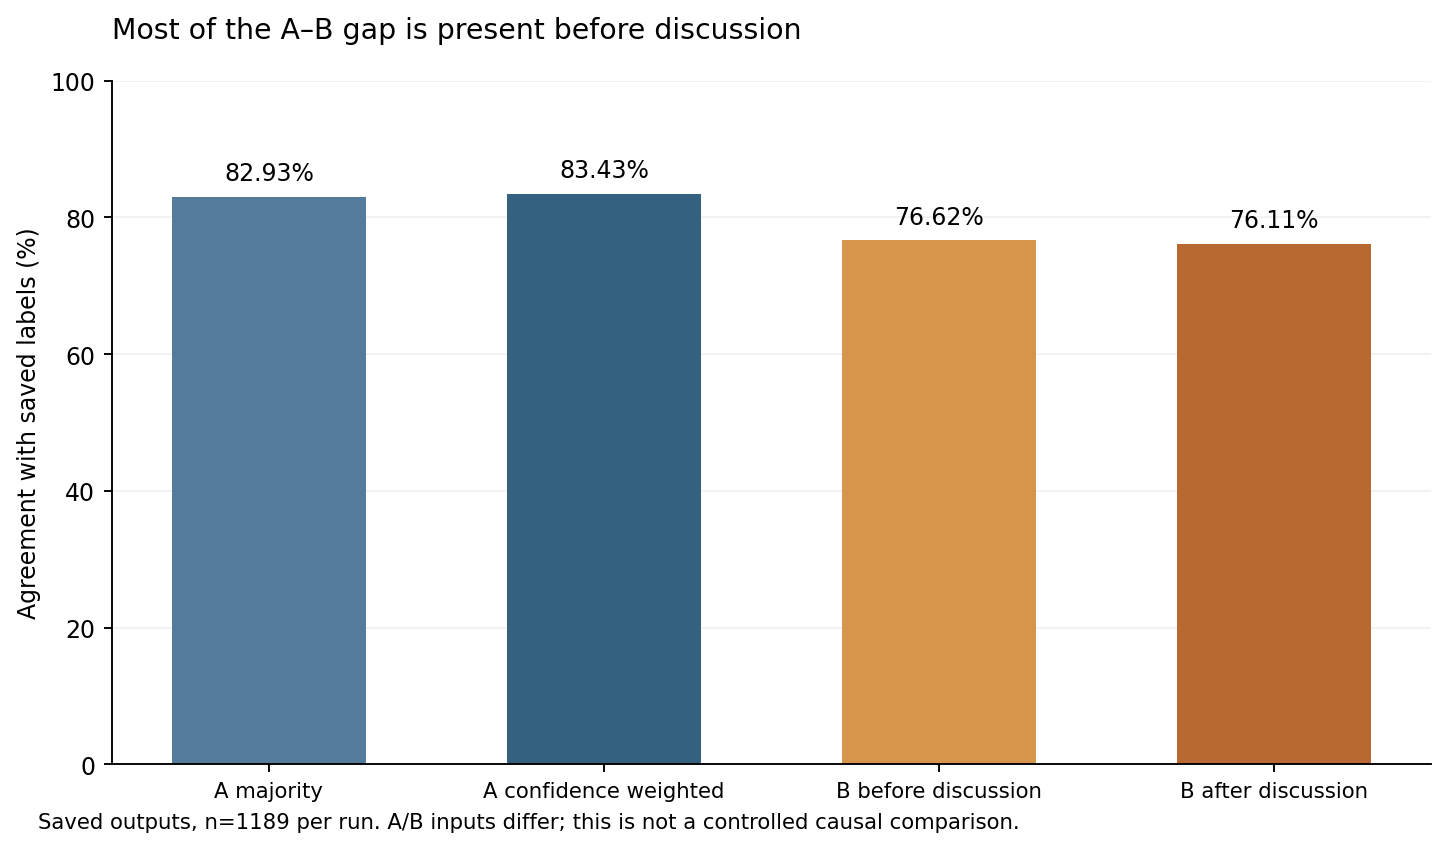

In [3]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8.4, 4.7), layout='constrained')
values = [audit['metrics'][k]['accuracy'] * 100 for k in names]
bars = ax.bar(list(names.values()), values, color=['#557b9c','#34617f','#d5954b','#b86932'], width=.58)
ax.set_ylim(0, 100)
ax.set_ylabel('Agreement with saved labels (%)')
ax.set_title('Most of the A–B gap is present before discussion', loc='left', pad=18)
ax.bar_label(bars, labels=[f'{v:.2f}%' for v in values], padding=5)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=.16)
ax.set_axisbelow(True)
ax.tick_params(axis='x', labelsize=9)
fig.text(.02, -.025, 'Saved outputs, n=1189 per run. A/B inputs differ; this is not a controlled causal comparison.', fontsize=9)
out = ROOT / 'results/audit_comparison.png'
fig.savefig(out, dpi=170, bbox_inches='tight')
fig.savefig(ROOT / 'results/audit_comparison.svg', bbox_inches='tight')
from IPython.display import display, Image
display(Image(filename=str(out)))
plt.close(fig)

## Сопоставление входов

`question_id` в evaluation равен `series_ticker`. Полный текст условий и стабильный идентификатор контракта необходимы для pairing. Различающиеся входы не следует автоматически объявлять ложными labels: возможны разные версии выгрузки.

In [4]:
r = audit['result_alignment']
print('Input differences after whitespace normalization:', r['input_semantic_multiset_difference'])
for key in ['paper_text_truth_occurrence','strict_semantic_occurrence']:
    x = audit['paired'][key]
    print(key, 'pairs:', x['pairs'], 'criteria mismatches:', x['criteria_mismatch'])
with (ROOT / 'audit/input_result_mismatches.csv').open() as f:
    mismatches = list(csv.DictReader(f))
print('Different labels among position mismatches:', sum(r['input_truth'].upper() != r['result_truth'].upper() for r in mismatches))
example = next(r for r in mismatches if r['input_id'] == 'KXADP')
print('Example criteria in input:', example['input_criteria'])
print('Example criteria in A:', example['result_criteria'])

Input differences after whitespace normalization: {'A': {'extra': 35, 'missing': 35}, 'B': {'extra': 0, 'missing': 0}}
paper_text_truth_occurrence pairs: 1170 criteria mismatches: 16
strict_semantic_occurrence pairs: 1154 criteria mismatches: 0
Different labels among position mismatches: 8
Example criteria in input: If the ADP Employment Change in Oct 2025 is above 50000, then the market resolves to Yes.
Example criteria in A: If the ADP Employment Change in Oct 2025 is above 75000, then the market resolves to Yes.


## Ошибки в уверенном единогласном подмножестве

Этот порог выбран по той же выборке, поэтому полученное качество не является оценкой фиксированной политики на независимом тесте. Причины ошибок требуют исходных evidence packets и ручного аудита.

In [5]:
s = audit['A_unanimous_high_confidence']
print(json.dumps(s, ensure_ascii=False, indent=2))
with (ROOT / 'audit/high_confidence_unanimous_errors.csv').open() as f:
    cases = list(csv.DictReader(f))
for row in cases:
    print(row['question_id'], '| prediction:', row['final_decision'], '| label:', row['ground_truth'], '|', row['question_text'])

{
  "threshold_same_sample_median": 0.91,
  "selected": 563,
  "correct": 551,
  "errors": 12,
  "coverage": 0.4735071488645921,
  "accuracy": 0.9786856127886323,
  "accuracy_wilson_95": [
    0.9631171520260569,
    0.9877660122389249
  ],
  "warning": "Same-sample selection, correlated groups; naive row-wise interval descriptive only"
}
KXNFLFIRSTTD | prediction: NO | label: YES | Baltimore at Cleveland: First Touchdown Scorer: Cleveland D/ST
KXDEBTSHRINK | prediction: NO | label: YES | Will the national debt shrink at any point during the Trump Administration?
KXTARIFFPHARMA | prediction: YES | label: NO | Will the U.S. impose tariffs on pharmaceuticals from any country in Sep 2025-Sep 2026?
KXBIDENMENTION | prediction: NO | label: YES | What will Joe Biden say during Ben Nelson Gala on November 7th?
KXFLIGHTJFK | prediction: YES | label: NO | Will there be more than 600 delays and cancellations at JFK on November 13, 2025?
KXOPENSOURCEOAI | prediction: NO | label: YES | What will O

## Статистическая точность и экономика

Биномиальная граница применима к независимым принятым случаям и заранее фиксированному gate. Для опубликованного post-hoc подмножества ниже она лишь иллюстративна. Денежные параметры — предположения, не измеренные расходы платформы. Brier/ECE из audit JSON интерпретируют self-reported confidence как вероятность корректности; это отдельное допущение.

In [6]:
subprocess.run([sys.executable, str(ROOT / 'src/risk_and_cost.py')], capture_output=True, text=True, check=True)
risk = json.loads((ROOT / 'results/risk_and_cost.json').read_text())
print('Required zero-error independent accepted cases:', risk['zero_error_required_independent_accepted_cases'])
print('Illustrative one-sided upper bound:', risk['one_sided_95pct_binomial_error_upper_bound_assuming_iid_fixed_gate'])
for row in risk['cost_scenarios']:
    print('Error loss:', row['loss_per_wrong_automatic_resolution_usd'], 'hybrid cost:', round(row['hybrid_cost_per_incoming_question_usd'], 2))
print('Assumed break-even loss:', round(risk['break_even_loss_usd'], 2))

Required zero-error independent accepted cases: {'0.05': 59, '0.01': 299, '0.005': 598, '0.001': 2995}
Illustrative one-sided upper bound: 0.03430550350120018
Error loss: 10 hybrid cost: 2.78
Error loss: 100 hybrid cost: 3.69
Error loss: 1000 hybrid cost: 12.77
Error loss: 10000 hybrid cost: 103.61
Assumed break-even loss: 229.63


## Реальная выгрузка Kalshi

Это convenience sample для проверки доступа, а не репрезентативный resolution benchmark. Исторические версии правил и доказательств не восстановлены. Прямые outcome-поля удалены из inputs, но timestamps и тексты тоже требуют проверки на утечки.

In [7]:
smoke = json.loads((ROOT / 'results/data_smoke_test.json').read_text())
print(json.dumps({k:v for k,v in smoke.items() if k not in ['files','missing_full_series_metadata_ids','warnings','field_completeness']}, ensure_ascii=False, indent=2))
inputs = [json.loads(s) for s in (ROOT / 'data/kalshi/inputs.jsonl').read_text().splitlines()]
labels = [json.loads(s) for s in (ROOT / 'data/kalshi/labels.jsonl').read_text().splitlines()]
print('Input records:', len(inputs), '| label records:', len(labels))
print('Input fields:', sorted(inputs[0]))
assert len(inputs) == len(labels) == 100
for row in inputs:
    assert not ({'result','settlement_ts','last_price','yes_bid','yes_ask','status','expiration_value'} & set(row))
print('Direct outcome-field check passed. Temporal eligibility remains unverified.')

{
  "run_id": "20260929T224128915577Z",
  "sample_kind": "convenience_sample_smoke_test_not_benchmark",
  "started_at": "2026-09-29T22:41:28.915374Z",
  "completed_at": "2026-09-29T22:41:40.726374Z",
  "requested_limit": 100,
  "raw_market_count": 100,
  "market_count": 100,
  "excluded_counts": {},
  "pagination_followed": false,
  "additional_page_available": true,
  "api_returned_status_counts": {
    "finalized": 100
  },
  "label_counts": {
    "no": 67,
    "yes": 33
  },
  "category_counts": {
    "Sports": 50,
    "Climate and Weather": 50
  },
  "unique_events": 32,
  "duplicate_event_group_count": 14,
  "markets_in_duplicate_event_groups": 82,
  "excess_rows_beyond_one_per_event": 68,
  "duplicate_event_groups": {
    "KXTEMPCHIHS-26SEP2917": 10,
    "KXTEMPLAXHS-26SEP2917": 10,
    "KXTEMPMIAH-26SEP2917": 10,
    "KXTEMPNYCHS-26SEP2917": 10,
    "KXTEMPNYCHS-26SEP2918": 10,
    "KXTTELITEMATCH-26SEP291700JNOOLU": 2,
    "KXTTELITEMATCH-26SEP291755MGRSJA": 2,
    "KXTTELITEMA

## Следующий проверяемый шаг

Выбрать 10 независимых текстовых контрактов и разметить действовавшие правила, момент доступности источников и достаточность evidence. Затем проверить H1: калибратор с признаками evidence против калибратора только по confidence на одних ответах resolver. Порог, primary error, splits и критерий поддержки заморозить до теста.

Сохранённые артефакты позволяют уже сейчас обсуждать воспроизводимость, причинные выводы и экономическую постановку. Они не подтверждают качество нового агента или выполнение экономического критерия.